# Goal: Inspect the period- eccentricity distribution 
Can we find any correlations:
- in (total) mass?
- per evolutionary type? 
- in total? 

(LvS: 06-02-26)

In [1]:
import json
import numpy as np
import pandas as pd
import sys, os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR, DOCS_DIR, LATEX_PLOT_DIR

file_path = MAIN_CATALOG


# Use mathtext (LaTeX-like without needing LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern math font
plt.rcParams['font.size'] = 12


### Read json catalog into pandas table

In [2]:
# === Load JSON ===
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

def extract_triplet_array(data, key):
    """Return an (N,3) float array for the given triplet key, robust to None/NaN."""
    rows = []
    for entry in data:
        val = entry.get(key, None)
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 3:
            try:
                # Convert None to np.nan before float conversion
                rows.append([
                    np.nan if val[0] is None else float(val[0]),
                    np.nan if val[1] is None else float(val[1]),
                    np.nan if val[2] is None else float(val[2])
                ])
            except (TypeError, ValueError):
                rows.append([np.nan, np.nan, np.nan])
        elif isinstance(val, (int, float)):
            # Scalar provided, treat as central value with unknown errors
            rows.append([np.nan, float(val), np.nan])
        else:
            rows.append([np.nan, np.nan, np.nan])
    return np.array(rows, dtype=float)

In [3]:
# Read data
data = read_json_file(str(MAIN_CATALOG))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)


In [4]:
# Extract triplet columns once for efficiency/consistency
RA_arr = extract_triplet_array(data, 'RA')
Dec_arr = extract_triplet_array(data, 'Dec')
period_arr = extract_triplet_array(data, 'Period')
ecc_arr = extract_triplet_array(data, 'Eccentricity')
m1_arr = extract_triplet_array(data, 'M1')
m2_arr = extract_triplet_array(data, 'M2')

# Build a single DataFrame with central values and errors
catalog_df = pd.DataFrame({
    'System Name': [entry.get('System Name', '') for entry in data],
    'RA': RA_arr[:, 1],
    'Dec': Dec_arr[:, 1],
    'Period': period_arr[:, 1],
    'Period_err_minus': period_arr[:, 0],
    'Period_err_plus': period_arr[:, 2],
    'Eccentricity': ecc_arr[:, 1],
    'Eccentricity_err_minus': ecc_arr[:, 0],
    'Eccentricity_err_plus': ecc_arr[:, 2],
    'M1': m1_arr[:, 1],
    'M1_err_minus': m1_arr[:, 0],
    'M1_err_plus': m1_arr[:, 2],
    'M2': m2_arr[:, 1],
    'M2_err_minus': m2_arr[:, 0],
    'M2_err_plus': m2_arr[:, 2],
    'obs_type_1': [entry.get('obs_type_1', '') for entry in data],
    'obs_type_2': [entry.get('obs_type_2', '') for entry in data],
    'evol_type_1': [entry.get('evol_type_1', '') for entry in data],
    'evol_type_2': [entry.get('evol_type_2', '') for entry in data],
    'system_class': [entry.get('system_class', 'None') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})

In [5]:
display(catalog_df)

,System Name,RA,Dec,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,...,M1_err_plus,M2,M2_err_minus,M2_err_plus,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
0,Cl* NGC 188 PKM 451,8.700020,85.540940,722.000000,4.000000e+00,4.000000e+00,0.34,0.03,0.03,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
1,Cl* NGC 188 PKM 1888,13.631330,85.535900,2240.000000,3.000000e+01,3.000000e+01,0.21,0.04,0.04,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
2,Cl* NGC 188 PKM 2679,6.685930,85.310000,1033.000000,8.000000e+00,8.000000e+00,0.07,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
3,Cl* NGC 188 PKM 4348,10.923210,85.221480,1168.000000,8.000000e+00,8.000000e+00,0.09,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4,Cl* NGC 188 PKM 4540,11.326540,85.322200,3030.000000,7.000000e+01,7.000000e+01,0.36,0.07,0.07,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4704,UCAC4 495-142916,297.473341,8.904363,0.748668,1.600000e-06,1.600000e-06,NaN,NaN,NaN,1.69,...,0.07,0.31,0.07,0.07,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4705,CRTS J225539.4+342138,118.713529,34.360512,0.571785,3.000000e-07,3.000000e-07,NaN,NaN,NaN,1.40,...,0.04,0.26,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4706,UCAC4 646-116578,123.282814,39.139678,0.766129,3.800000e-06,3.800000e-06,NaN,NaN,NaN,1.60,...,0.08,0.16,0.05,0.05,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4707,ZTF J225755.64+310133.7,127.228463,31.026046,0.688416,4.000000e-07,4.000000e-07,NaN,NaN,NaN,1.65,...,0.06,0.29,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [6]:
# Create discrete color map between 
WD_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#e6cfd9', '#a5678e'])
WDcolors = [mcolors.rgb2hex(WD_cmap(i)) for i in np.linspace(0, 1, 7)]

stripped_star_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#82c9ed', '#366de2']) #BDDEF4 #1b478e
strippedstar_colors = [mcolors.rgb2hex(stripped_star_cmap(i)) for i in np.linspace(0, 1, 4)]

compact_object_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#bde256', '#0c9e27'])
compact_obj_colors = [mcolors.rgb2hex(compact_object_cmap(i)) for i in np.linspace(0, 1, 4)]

SYSTEM_CLASS_MAP = {
    # Binaries containing white dwarfs
    'WD binary':{'Astrometric WD + MS': {'color': WDcolors[0], 'symbol': 'circle'},                  # light purple
    'Spectroscopic WD + MS': {'color': WDcolors[1], 'symbol': 'cross-dot'},                  # light purple
    'WD + MS': {'color': WDcolors[2], 'symbol': 'pentagon'},                  # left over ones (come from Krukow paper 2021ApJ...920...86K)
    'Blue straggler binary': {'color': WDcolors[3], 'symbol': 'hourglass'}, # yellow
    'Chemically Peculiar': {'color': WDcolors[4], 'symbol': 'square'}, # gray  
    },

    'Transition to WD':{'EL CVn': {'color': '#FF6692', 'symbol': 'star'},         # orange
    'post AGB': {'color': '#ea4d4d', 'symbol': 'cross'},           # coral/red
    },

    # Binaries w. non-degenerate components
    'Ongoing RLOF': {'Contact binary': {'color': '#eda45c', 'symbol': 'triangle-up'},           # orange
    'Algol': {'color': '#d65906', 'symbol': 'diamond'},                   # maroon
    },

    'Stripped component': {'Hot subdwarf': {'color': strippedstar_colors[0], 'symbol': 'pentagon-open'},             # UV purple
    'Stripped star': {'color': strippedstar_colors[1], 'symbol': 'x'},  # muted green
    'WR binary': {'color': strippedstar_colors[2], 'symbol': 'triangle-up'},       # blue
    },

    # Binaries containing neutron stars or black holes
    'CO binary': {'pulsar binary': {'color': compact_obj_colors[0], 'symbol': 'diamond-tall'},           # lime green
    'high-mass XRB': {'color': compact_obj_colors[1], 'symbol': 'square'},             # muted green
    'Spectroscopic compact object': {'color': compact_obj_colors[2], 'symbol': 'x'},  # yellow green
    'Astrometric compact object': {'color': compact_obj_colors[3], 'symbol': 'circle-open'},  # muted green
    },
}

In [7]:
# Helper function to increase darkness of a color
def darken_color(color, factor=0.7):
    """
    Darken a color by multiplying its RGB values by a factor.
    
    Parameters:
    -----------
    color : str or tuple
        Color as hex string (e.g., '#FF0000') or RGB tuple
    factor : float
        Factor to darken by (0-1). Lower = darker. Default 0.7
        
    Returns:
    --------
    str : Darkened color as hex string
    """
    import matplotlib.colors as mcolors
    
    # Convert to RGB if it's a hex string
    rgb = mcolors.to_rgb(color)
    
    # Multiply each channel by the factor
    darkened_rgb = tuple(c * factor for c in rgb)
    
    # Convert back to hex
    return mcolors.to_hex(darkened_rgb)

# Example usage:
# darker_green = darken_color(mass_colors[0], factor=0.6)
# ax.plot(x, y, color=darker_green)

# Plot the P-e distribution colored by mass

/var/folders/5d/vcxrsh5975l7d5n8t7vvc5pr0000gn/T/ipykernel_61058/3565312856.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = plot_df.groupby('P_bin')['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()


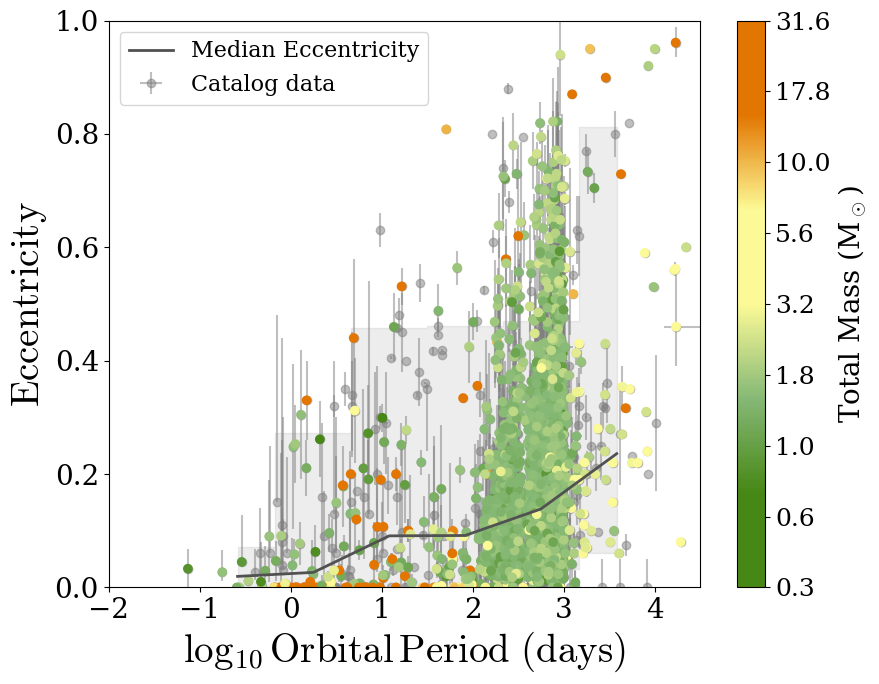

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()

plot_df['log_Period'] = np.log10(plot_df['Period'])

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
period_err_minus_log = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
period_err_plus_log = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
period_err_minus_log = period_err_minus_log.fillna(0)
period_err_plus_log = period_err_plus_log.fillna(0)
ecc_err_minus = plot_df['Eccentricity_err_minus'].fillna(0)
ecc_err_plus = plot_df['Eccentricity_err_plus'].fillna(0)


###### Actual plotting ######
## P vs e inlcuding errors ##
ax.errorbar(plot_df['log_Period'], (plot_df['Eccentricity']),
            xerr=[period_err_minus_log, period_err_plus_log], 
            yerr=[ecc_err_minus, ecc_err_plus], zorder = 0,
            fmt='o', c='gray', alpha=0.5, label = 'Catalog data')  

## Show Median and 1-sigma ##
P_bins = np.linspace(-1,4, 7)
plot_df['P_bin'] = pd.cut(plot_df['log_Period'], bins=P_bins)
stats = plot_df.groupby('P_bin')['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()
stats.columns = ['p05', 'median', 'p95']

x_stats = P_bins[:-1] + 0.5 * np.diff(P_bins)
plt.plot(x_stats, stats['median'].values, lw=2, c = '#515151', label = 'Median Eccentricity')
plt.fill_between(x_stats, stats['p05'].values, stats['p95'].values, color='#515151', alpha=0.1, step='mid', zorder=-1)

## Now overplot colored by total mass ##
plot_df['Mtot'] = plot_df['M1'] + plot_df['M2']
plot_df['log_Mtot'] = np.log10(plot_df['Mtot'])
mass_color_key = 'log_Mtot'

#enforce not na for all three parameters of interest (log_Period, Eccentricity, Mtot)
plot_df = plot_df.dropna(subset=['log_Period', 'Eccentricity', mass_color_key])
mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#478716', '#478716', '#86b976', '#fcfa96', '#fcfa96','#e37601','#e37601'])

mass_sc = ax.scatter(plot_df['log_Period'], plot_df['Eccentricity'], 
                    c = plot_df[mass_color_key], cmap=mass_cmap,
                    vmin = -0.5, vmax=1.5)  # Set vmin and vmax for consistent color scaling
cbar = plt.colorbar(mass_sc, ax=ax)


# Set colorbar ticks to show original (non-log) values
tick_locs = cbar.get_ticks() # Get the current tick positions (in log space)
tick_labels = [f'{10**tick:.1f}' for tick in tick_locs] # Convert back from log10 to original values
cbar.set_ticks(tick_locs, labels=tick_labels)

cbar.set_label('Total Mass (M$_\odot$)', fontsize=20)
cbar.ax.tick_params(labelsize=18)


###### Plot values ######
plt.xlim(-2,4.5)
plt.ylim(0,1)
# ax.set_xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=28)
plt.ylabel('$\mathrm{Eccentricity}$', fontsize=28)
plt.tight_layout()
ax.legend(fontsize=16)
plt.savefig(LATEX_PLOT_DIR / 'P_e_diagram_cmass_median.pdf')
plt.savefig(PLOTS_DIR / 'P_e_diagram_cmass_median.pdf')
plt.show()

In [9]:
# Alternative colormaps 
# # mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#afcfce', '#99b6a0', '#368979','#2a7595','#0d3d47'])
# mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#d3e29d', '#acc864', '#8ab446','#2d6b22','#072a16'])
# mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#6f9c3d', '#a5c90f', '#fcfa96','#ed6c10','#9c3842'])
# mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#6a9c43', '#86b976', '#8fbc93','#d3dbb4','#e37601'])

# P-e distribution per category

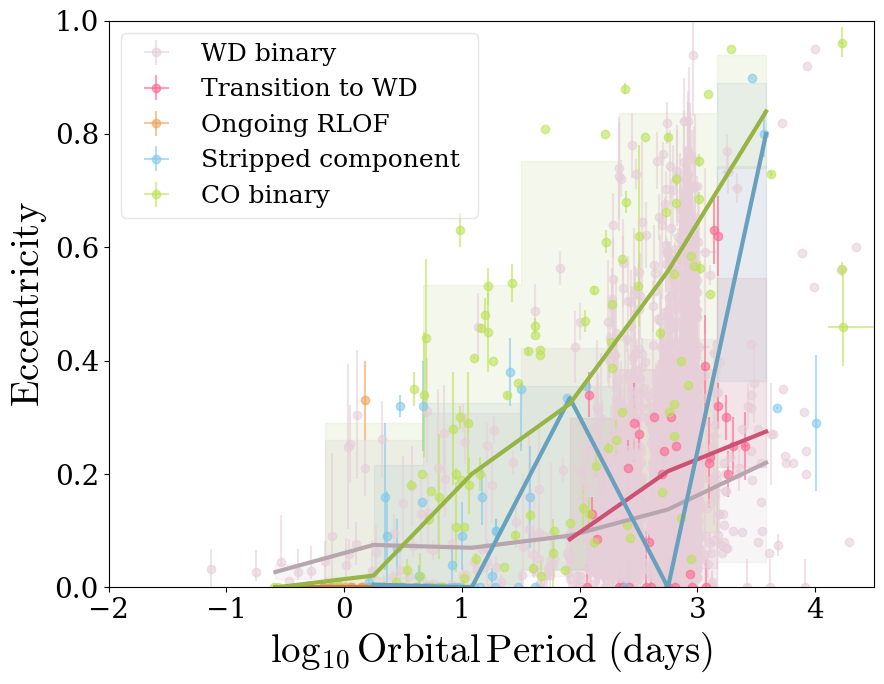

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))


plot_df = catalog_df.copy()

plot_df['log_Period'] = np.log10(plot_df['Period'])

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
plot_df['Eccentricity_err_minus'] = plot_df['Eccentricity_err_minus'].fillna(0)
plot_df['Eccentricity_err_plus'] = plot_df['Eccentricity_err_plus'].fillna(0)

# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    
    # Combine all system classes in this category
    system_classes_in_category = list(systems.keys())
    subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)].copy()
    log_periods = np.log10(subset['Period'].dropna())
    
    first_system_color = list(systems.values())[0]['color']

    ###### Actual plotting ######
    ax.errorbar(subset['log_Period'], (subset['Eccentricity']),
                xerr=[subset['period_err_minus_log'], subset['period_err_plus_log']], 
                yerr=[subset['Eccentricity_err_minus'].fillna(0), subset['Eccentricity_err_plus'].fillna(0)], zorder = 0,
                fmt='o', c=first_system_color, alpha=0.6,
                label=f"{category} ")  

    ## Show Median and 1-sigma ##
    P_bins = np.linspace(-1,4, 7)
    subset['P_bin'] = pd.cut(subset['log_Period'], bins=P_bins)
    stats = subset.groupby('P_bin', observed=False)['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()
    stats.columns = ['p05', 'median', 'p95']

    x_stats = P_bins[:-1] + 0.5 * np.diff(P_bins)
    # ax.plot(x_stats, stats['p05'].values, lw=2, ls = ':', c = darken_color(first_system_color, factor=0.8))
    ax.plot(x_stats, stats['median'].values, lw=3, c = darken_color(first_system_color, factor=0.8))
    # ax.plot(x_stats, stats['p95'].values, lw=2, ls = ':', c = darken_color(first_system_color, factor=0.8))
    ax.fill_between(x_stats, stats['p05'].values, stats['p95'].values, color=darken_color(first_system_color, factor=0.8), alpha=0.1, step='mid', zorder=-1)


# Plot formatting
# Set tick labels to be larger and use mathtext for the x-axis
plt.xlim(-2,4.5)
plt.ylim(0,1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=28)
plt.ylabel('$\mathrm{Eccentricity}$', fontsize=28)
plt.legend(loc='upper left', fontsize=18, framealpha = 0.5)#bbox_to_anchor=(0.05, 0.95),
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'P_e_by_category_median.pdf')
plt.savefig(PLOTS_DIR / 'P_e_by_category_median.pdf')
plt.show()

# P-e colored by mass, including an overal polynomial fit

Polynomial coefficients: [ 0.0125308  -0.05288448  0.0913593   0.05598906]
Fit equation:          3           2
0.01253 x - 0.05288 x + 0.09136 x + 0.05599


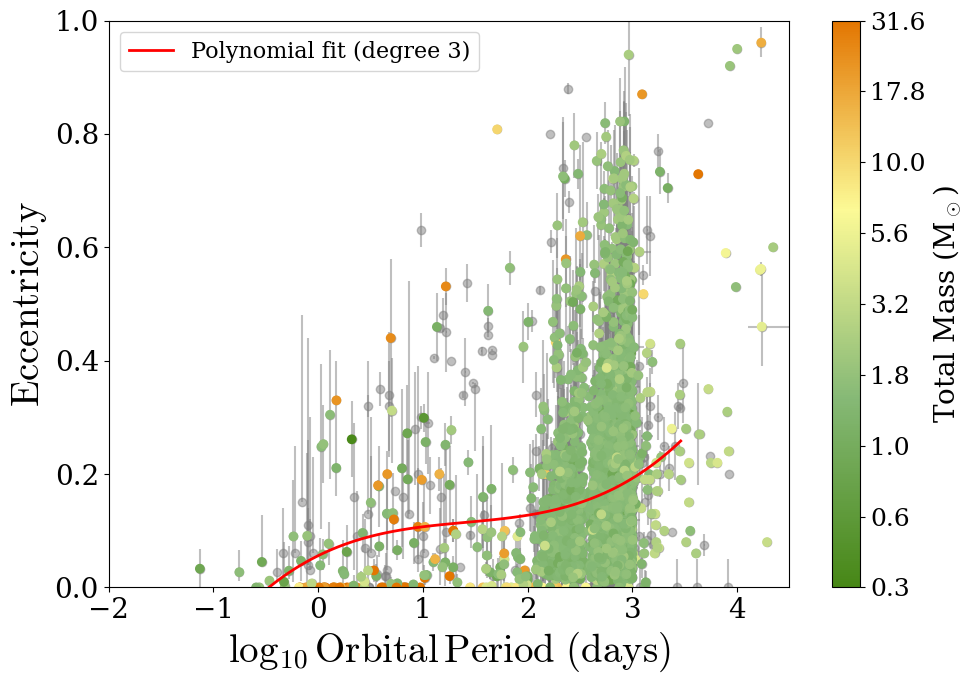

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_df = catalog_df.copy()

plot_df['log_Period'] = np.log10(plot_df['Period'])

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
period_err_minus_log = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
period_err_plus_log = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
period_err_minus_log = period_err_minus_log.fillna(0)
period_err_plus_log = period_err_plus_log.fillna(0)
ecc_err_minus = plot_df['Eccentricity_err_minus'].fillna(0)
ecc_err_plus = plot_df['Eccentricity_err_plus'].fillna(0)


###### Actual plotting ######
## P vs e inlcuding errors ##
ax.errorbar(plot_df['log_Period'], (plot_df['Eccentricity']),
            xerr=[period_err_minus_log, period_err_plus_log], 
            yerr=[ecc_err_minus, ecc_err_plus], zorder = 0,
            fmt='o', c='gray', alpha=0.5)  

## Show Median and 1-sigma ##



## Now overplot colored by total mass ##
plot_df['Mtot'] = plot_df['M1'] + plot_df['M2']
plot_df['log_Mtot'] = np.log10(plot_df['Mtot'])
mass_color_key = 'log_Mtot'

#enforce not na for all three parameters of interest (log_Period, Eccentricity, Mtot)
plot_df = plot_df.dropna(subset=['log_Period', 'Eccentricity', mass_color_key])
mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#478716', '#86b976', '#fcfa96','#e37601'])

mass_sc = ax.scatter(plot_df['log_Period'], plot_df['Eccentricity'], 
                    c = plot_df[mass_color_key], cmap=mass_cmap,
                    vmin=-0.5, vmax=1.5)  # Set vmin and vmax for consistent color scaling
cbar = plt.colorbar(mass_sc, ax=ax)


# Set colorbar ticks to show original (non-log) values
tick_locs = cbar.get_ticks() # Get the current tick positions (in log space)
tick_labels = [f'{10**tick:.1f}' for tick in tick_locs] # Convert back from log10 to original values
cbar.set_ticks(tick_locs, labels=tick_labels)

cbar.set_label('Total Mass (M$_\odot$)', fontsize=20)
cbar.ax.tick_params(labelsize=18)


###### Add polynomal fit ######
# Prepare data for fitting (remove NaN values)
fit_df = plot_df.dropna(subset=['log_Period', 'Eccentricity'])

# Limit the fitting range (e.g., only fit data between log_Period = 0 and 3)
x_min, x_max = -1, 3.5
fit_df = fit_df[(fit_df['log_Period'] >= x_min) & (fit_df['log_Period'] <= x_max)]

# Use numpy polyfit (simpler, no errors needed)
degree = 3
coeffs = np.polyfit(fit_df['log_Period'], fit_df['Eccentricity'], deg=degree)

# Create polynomial function
poly_func = np.poly1d(coeffs)

# Generate smooth curve for plotting
x_fit = np.linspace(fit_df['log_Period'].min(), fit_df['log_Period'].max(), 100)
y_fit = poly_func(x_fit)

# Plot the fit
ax.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Polynomial fit (degree {degree})', zorder=10)

# Print coefficients to see what you got
print(f"Polynomial coefficients: {coeffs}")
print(f"Fit equation: {poly_func}")


###### Plot values ######
plt.xlim(-2,4.5)
plt.ylim(0,1)
# ax.set_xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=28)
plt.ylabel('$\mathrm{Eccentricity}$', fontsize=28)
plt.tight_layout()
ax.legend(fontsize=16)
plt.savefig(PLOTS_DIR / 'P_e_diagram_cmass_general_polyfit.pdf')
plt.show()

# P-e with polynomial fit per mass bin

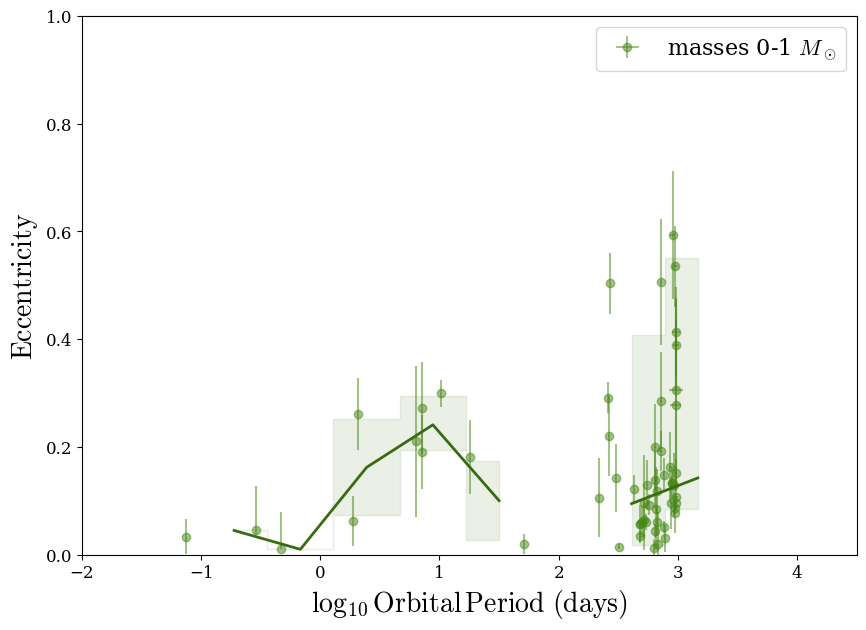

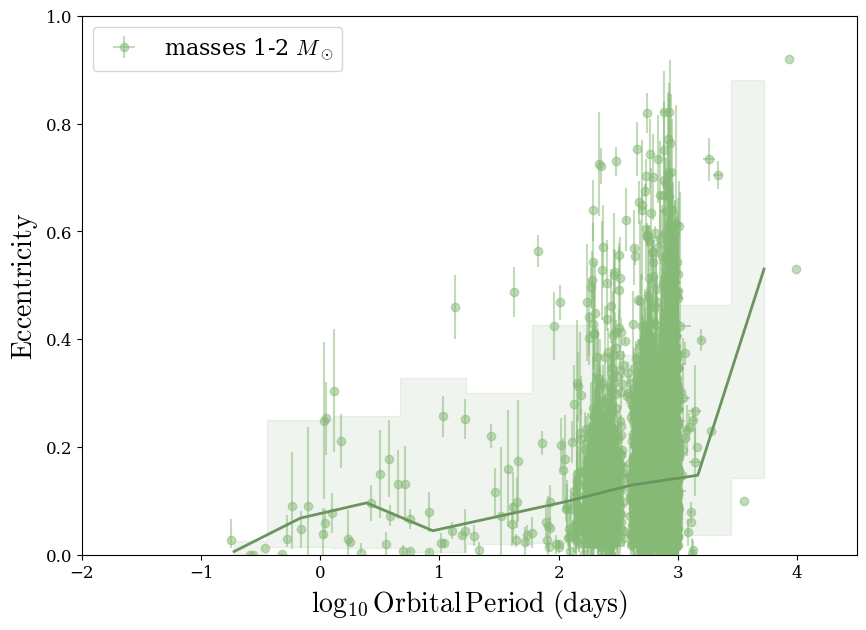

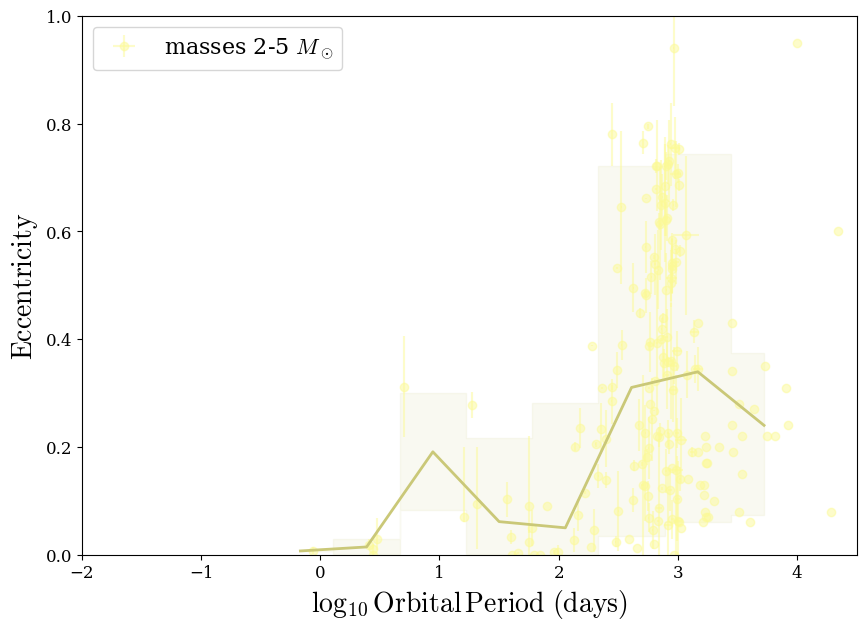

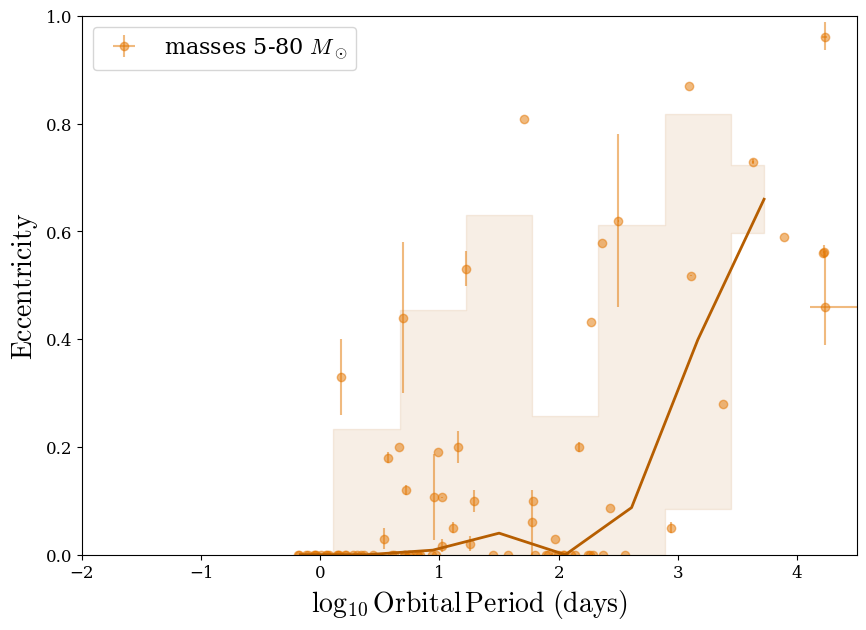

In [207]:
# fig, ax = plt.subplots(figsize=(10, 7))

# Prepare plot_df (this is missing!)
plot_df = catalog_df.copy()
plot_df['log_Period'] = np.log10(plot_df['Period'])
plot_df['Mtot'] = plot_df['M1'] + plot_df['M2']

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
ecc_err_minus = plot_df['Eccentricity_err_minus'].fillna(0)
ecc_err_plus = plot_df['Eccentricity_err_plus'].fillna(0)


mass_colors = ['#478716', '#86b976', '#fcfa96','#e37601']
mass_bin_edges = [0,1,2,5,80]
###### loop over bins in mass ######
for i in range(len(mass_bin_edges)-1):
    fig, ax = plt.subplots(figsize=(10, 7))

    mass_bin_df = plot_df[(plot_df['Mtot'] >= mass_bin_edges[i]) & (plot_df['Mtot'] < mass_bin_edges[i+1])].copy()

    ###### Actual plotting ######
    ax.errorbar(mass_bin_df['log_Period'], (mass_bin_df['Eccentricity']),
                xerr=[mass_bin_df['period_err_minus_log'], mass_bin_df['period_err_plus_log']], 
                yerr=[mass_bin_df['Eccentricity_err_minus'].fillna(0), mass_bin_df['Eccentricity_err_plus'].fillna(0)], zorder = 0,
                fmt='o', c=mass_colors[i], alpha=0.5, label = 'masses ' + str(mass_bin_edges[i]) + '-' + str(mass_bin_edges[i+1]) + ' $M_\\odot$')

    ## Show Median and 1-sigma ##
    P_bins = np.linspace(-1,4, 10)
    mass_bin_df['P_bin'] = pd.cut(mass_bin_df['log_Period'], bins=P_bins)
    stats = mass_bin_df.groupby('P_bin', observed=False)['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()
    stats.columns = ['p05', 'median', 'p95']

    x_stats = P_bins[:-1] + 0.5 * np.diff(P_bins)
    # ax.plot(x_stats, stats['p05'].values, lw=2, ls = ':', c = darken_color(mass_colors[i], factor=0.8))
    ax.plot(x_stats, stats['median'].values, lw=2, c = darken_color(mass_colors[i], factor=0.8))
    # ax.plot(x_stats, stats['p95'].values, lw=2, ls = ':', c = darken_color(mass_colors[i], factor=0.8))
    ax.fill_between(x_stats, stats['p05'].values, stats['p95'].values, color=darken_color(mass_colors[i], factor=0.8), alpha=0.1, step='mid', zorder=-1)
    
    # ###### Add polynomal fit ######
    # # Prepare data for fitting (remove NaN values)
    # fit_df = mass_bin_df.dropna(subset=['log_Period', 'Eccentricity'])

    # # Limit the fitting range (e.g., only fit data between log_Period = 0 and 3)
    # x_min, x_max = -1, 3.9
    # fit_df = fit_df[(fit_df['log_Period'] >= x_min) & (fit_df['log_Period'] <= x_max)]

    # # Use numpy polyfit (simpler, no errors needed)
    # degree = 4
    # coeffs = np.polyfit(fit_df['log_Period'], fit_df['Eccentricity'], deg=degree)

    # # Create polynomial function
    # poly_func = np.poly1d(coeffs)

    # # Generate smooth curve for plotting
    # x_fit = np.linspace(fit_df['log_Period'].min(), fit_df['log_Period'].max(), 100)
    # y_fit = poly_func(x_fit)

    # # Plot the fit
    # ax.plot(x_fit, y_fit, ls ='--', color = darken_color(mass_colors[i], factor=0.8) , linewidth=2, label=f'Polynomial fit (degree {degree})', zorder=10)
    # # Print coefficients to see what you got
    # print(f"Polynomial coefficients: {coeffs}")
    # print(f"Fit equation: {poly_func}")


    ###### Plot values ######
    ax.set_ylim(0, 1)  # Eccentricity is bounded [0,1]
    ax.set_xlim(-2, 4.5)

    ax.legend(fontsize=16)
    plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=20)
    plt.ylabel('$\mathrm{Eccentricity}$', fontsize=20)
    plt.savefig(PLOTS_DIR / f'P_e_diagram_cmass_massbin_{mass_bin_edges[i]}_{mass_bin_edges[i+1]}.pdf')
    plt.show()
